In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from statsmodels.stats.multitest import multipletests

In [3]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

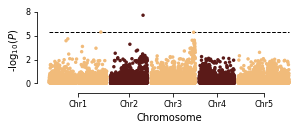

In [4]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
classic=parse('FO_leaf_B_blues.assoc.txt.gz')
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(12*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylim(-1,8)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("Fig3a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [6]:
classic.loc[classic['chr'] == 3].sort_values(by='P',ascending=False).head(5)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
7551,3,3:22436584,22436584,2,A,T,0.395,11.362140,2.225866,6.746193,6.750855,0.000001,0.000004,0.000057,5.364496,-5.364496,76562544
7583,3,3:22827669,22827669,11,C,A,0.400,9.007215,1.947320,6.989126,7.097283,0.000009,0.000030,0.000209,4.527099,-4.527099,76953629
7453,3,3:21656886,21656886,3,G,A,0.301,9.949179,2.233000,8.455331,8.520636,0.000018,0.000030,0.000151,4.522875,-4.522875,75782846
7567,3,3:22632105,22632105,8,A,G,0.381,9.225086,2.029157,7.258451,7.344480,0.000013,0.000035,0.000231,4.451054,-4.451054,76758065
7594,3,3:23003946,23003946,7,A,T,0.353,9.961674,2.308816,8.489446,8.576995,0.000032,0.000053,0.000236,4.279534,-4.279534,77129906


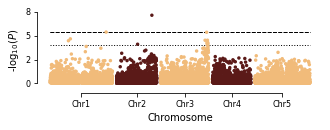

In [11]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
# classic=parse('SA_leaf_B_blues_kship.assoc.txt.gz')
rejected, pvals_corrected, _, _ = multipletests(classic['p_lrt'], alpha=0.1, method='fdr_bh')
classic["Significant"] = rejected
classic["FDR_corrected_pval"] = pvals_corrected
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(13*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
plt.hlines(y=classic[classic["Significant"] == True]['P'].min(),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylim(-1,8)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.savefig("Fig3a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)